# Analisis Exploratorio de Datos (EDA) - Patient Segmentation Dataset

**Archivo:** `3_patient_segmentation_dataset.csv`

Este notebook realiza un analisis exploratorio completo del dataset de segmentacion de pacientes. El dataset contiene 16 columnas con informacion demografica, medica, de seguros y de comportamiento de pacientes.

**Columnas del dataset:**
- `PatientID`, `Age`, `Gender`, `State`, `City`
- `Height_cm`, `Weight_kg`, `BMI`
- `Insurance_Type`, `Primary_Condition`, `Num_Chronic_Conditions`
- `Annual_Visits`, `Avg_Billing_Amount`, `Last_Visit_Date`
- `Days_Since_Last_Visit`, `Preventive_Care_Flag`

---
## Seccion 0: Setup y carga de datos

Montamos Google Drive (o subimos el archivo manualmente) e importamos las librerias necesarias.

In [7]:
# === OPCION 1: Carga LOCAL (usar esta si corres en tu PC) ===
filepath = '3_patient_segmentation_dataset.csv'

# === OPCION 2: Montar Google Drive ===
# from google.colab import drive
# drive.mount('/content/drive')
# filepath = '/content/drive/MyDrive/RUTA_A_TU_ARCHIVO/3_patient_segmentation_dataset.csv'

# === OPCION 3: Subir archivo manualmente en Colab ===
# from google.colab import files
# uploaded = files.upload()
# filepath = '3_patient_segmentation_dataset.csv'

In [2]:
# Instalar librerias necesarias (descomentar si no las tenes instaladas)
# !pip install pandas numpy matplotlib seaborn plotly nbformat
# pip install pandas numpy matplotlib seaborn plotly nbformat

In [3]:
# Importar librerias
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import nbformat

warnings.filterwarnings('ignore')
%matplotlib inline

# Estilo de graficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Librerias importadas correctamente.')

Librerias importadas correctamente.


In [8]:
# Cargar el dataset
# Ajusta la ruta segun la opcion que hayas elegido arriba
filepath = '3_patient_segmentation_dataset.csv'

df = pd.read_csv(filepath, parse_dates=['Last_Visit_Date'])
print(f'Dataset cargado exitosamente: {df.shape[0]} filas x {df.shape[1]} columnas')

Dataset cargado exitosamente: 2000 filas x 16 columnas


---
## Seccion 1: Primera vista del dataset

Revisamos la estructura general del dataset: dimensiones, tipos de datos, primeras filas y estadisticas descriptivas.

In [9]:
# Dimensiones del dataset
print(f'Dimensiones del dataset: {df.shape}')
print(f'Numero de filas: {df.shape[0]}')
print(f'Numero de columnas: {df.shape[1]}')
print()

# Primeras filas
print('=== Primeras 5 filas ===')
df.head()

Dimensiones del dataset: (2000, 16)
Numero de filas: 2000
Numero de columnas: 16

=== Primeras 5 filas ===


,PatientID,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
0,P10000,64,Male,GA,Unknown,151,115,50.4,Private,Arthritis,3,7,2995.0,2025-07-18,186,0
1,P10001,59,Male,OH,Unknown,189,68,19.0,Medicare,Depression,1,8,1209.0,2025-12-12,39,0
2,P10002,58,Female,PA,Unknown,156,91,37.4,Private,Asthma,1,4,999.0,2025-09-16,126,0
3,P10003,43,Female,GA,Unknown,152,92,39.8,Medicare,Hypertension,1,6,5638.5,2025-04-09,286,1
4,P10004,53,Female,NC,Unknown,167,51,18.3,Medicaid,Asthma,1,4,5796.0,2025-03-07,319,0


In [10]:
# Informacion general del dataset
print('=== Informacion del dataset ===')
df.info()

=== Informacion del dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   PatientID               2000 non-null   object        
 1   Age                     2000 non-null   int64         
 2   Gender                  2000 non-null   object        
 3   State                   2000 non-null   object        
 4   City                    2000 non-null   object        
 5   Height_cm               2000 non-null   int64         
 6   Weight_kg               2000 non-null   int64         
 7   BMI                     2000 non-null   float64       
 8   Insurance_Type          2000 non-null   object        
 9   Primary_Condition       1505 non-null   object        
 10  Num_Chronic_Conditions  2000 non-null   int64         
 11  Annual_Visits           2000 non-null   int64         
 12  Avg_Billing_Amou

In [11]:
# Tipos de datos
print('=== Tipos de datos ===')
print(df.dtypes)
print()
print(f'Columnas numericas: {df.select_dtypes(include=np.number).columns.tolist()}')
print(f'Columnas categoricas: {df.select_dtypes(include="object").columns.tolist()}')
print(f'Columnas de fecha: {df.select_dtypes(include="datetime").columns.tolist()}')

=== Tipos de datos ===
PatientID                         object
Age                                int64
Gender                            object
State                             object
City                              object
Height_cm                          int64
Weight_kg                          int64
BMI                              float64
Insurance_Type                    object
Primary_Condition                 object
Num_Chronic_Conditions             int64
Annual_Visits                      int64
Avg_Billing_Amount               float64
Last_Visit_Date           datetime64[ns]
Days_Since_Last_Visit              int64
Preventive_Care_Flag               int64
dtype: object

Columnas numericas: ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Num_Chronic_Conditions', 'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit', 'Preventive_Care_Flag']
Columnas categoricas: ['PatientID', 'Gender', 'State', 'City', 'Insurance_Type', 'Primary_Condition']
Columnas de fecha: ['Last_Vis

In [12]:
# Estadisticas descriptivas - variables numericas
print('=== Estadisticas descriptivas (numericas) ===')
df.describe()

=== Estadisticas descriptivas (numericas) ===


,Age,Height_cm,Weight_kg,BMI,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
count,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000,2000.000000,2000.000000
mean,50.69550,167.907500,85.143500,30.740650,1.080000,5.466500,4000.270500,2025-07-23 21:57:36,180.085000,0.464000
min,18.00000,145.000000,50.000000,13.400000,0.000000,1.000000,207.000000,2025-01-20 00:00:00,1.000000,0.000000
25%,40.00000,158.000000,67.000000,23.800000,1.000000,3.000000,2061.000000,2025-04-27 00:00:00,90.000000,0.000000
50%,51.00000,168.000000,86.000000,30.100000,1.000000,4.000000,3707.250000,2025-07-21 00:00:00,183.000000,0.000000
75%,63.25000,177.000000,103.000000,37.025000,1.000000,8.000000,5650.875000,2025-10-22 00:00:00,268.000000,1.000000
max,87.00000,195.000000,120.000000,57.100000,3.000000,12.000000,12467.500000,2026-01-19 00:00:00,365.000000,1.000000
std,15.44445,12.684494,20.385428,8.839952,0.890504,3.485965,2463.239215,NaN,104.688484,0.498827


In [13]:
# Estadisticas descriptivas - variables categoricas
print('=== Estadisticas descriptivas (categoricas) ===')
df.describe(include='object')

=== Estadisticas descriptivas (categoricas) ===


,PatientID,Gender,State,City,Insurance_Type,Primary_Condition
count,2000,2000,2000,2000,2000,1505
unique,2000,2,10,20,4,9
top,P11983,Female,NC,Unknown,Medicare,Hypertension
freq,1,1001,213,1012,906,210


---
## Seccion 2: Valores nulos, duplicados y calidad de datos

Evaluamos la calidad del dataset: valores faltantes, registros duplicados, valores unicos y proporcion de valores "Unknown" en columnas geograficas.

In [14]:
# Valores nulos por columna
nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / len(df) * 100).round(2)

tabla_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos
}).sort_values('Nulos', ascending=False)

print('=== Valores nulos por columna ===')
print(tabla_nulos)
print(f'\nTotal de valores nulos en el dataset: {df.isnull().sum().sum()}')

=== Valores nulos por columna ===
                        Nulos  Porcentaje (%)
Primary_Condition         495           24.75
PatientID                   0            0.00
Gender                      0            0.00
Age                         0            0.00
City                        0            0.00
Height_cm                   0            0.00
Weight_kg                   0            0.00
State                       0            0.00
BMI                         0            0.00
Insurance_Type              0            0.00
Num_Chronic_Conditions      0            0.00
Annual_Visits               0            0.00
Avg_Billing_Amount          0            0.00
Last_Visit_Date             0            0.00
Days_Since_Last_Visit       0            0.00
Preventive_Care_Flag        0            0.00

Total de valores nulos en el dataset: 495


In [15]:
# Registros duplicados
duplicados = df.duplicated().sum()
print(f'Registros duplicados: {duplicados}')
print(f'Porcentaje de duplicados: {(duplicados / len(df) * 100):.2f}%')

# Duplicados por PatientID
dup_id = df['PatientID'].duplicated().sum()
print(f'\nPatientID duplicados: {dup_id}')

Registros duplicados: 0
Porcentaje de duplicados: 0.00%

PatientID duplicados: 0


In [16]:
# Valores unicos por columna
print('=== Valores unicos por columna ===')
for col in df.columns:
    print(f'{col}: {df[col].nunique()} valores unicos')

=== Valores unicos por columna ===
PatientID: 2000 valores unicos
Age: 68 valores unicos
Gender: 2 valores unicos
State: 10 valores unicos
City: 20 valores unicos
Height_cm: 51 valores unicos
Weight_kg: 71 valores unicos
BMI: 370 valores unicos
Insurance_Type: 4 valores unicos
Primary_Condition: 9 valores unicos
Num_Chronic_Conditions: 4 valores unicos
Annual_Visits: 12 valores unicos
Avg_Billing_Amount: 1794 valores unicos
Last_Visit_Date: 364 valores unicos
Days_Since_Last_Visit: 364 valores unicos
Preventive_Care_Flag: 2 valores unicos


In [17]:
# Proporcion de valores "Unknown" en State y City
for col in ['State', 'City']:
    if col in df.columns:
        unknown_count = (df[col] == 'Unknown').sum()
        unknown_pct = (unknown_count / len(df) * 100)
        print(f'{col}: {unknown_count} valores "Unknown" ({unknown_pct:.2f}%)')

State: 0 valores "Unknown" (0.00%)
City: 1012 valores "Unknown" (50.60%)


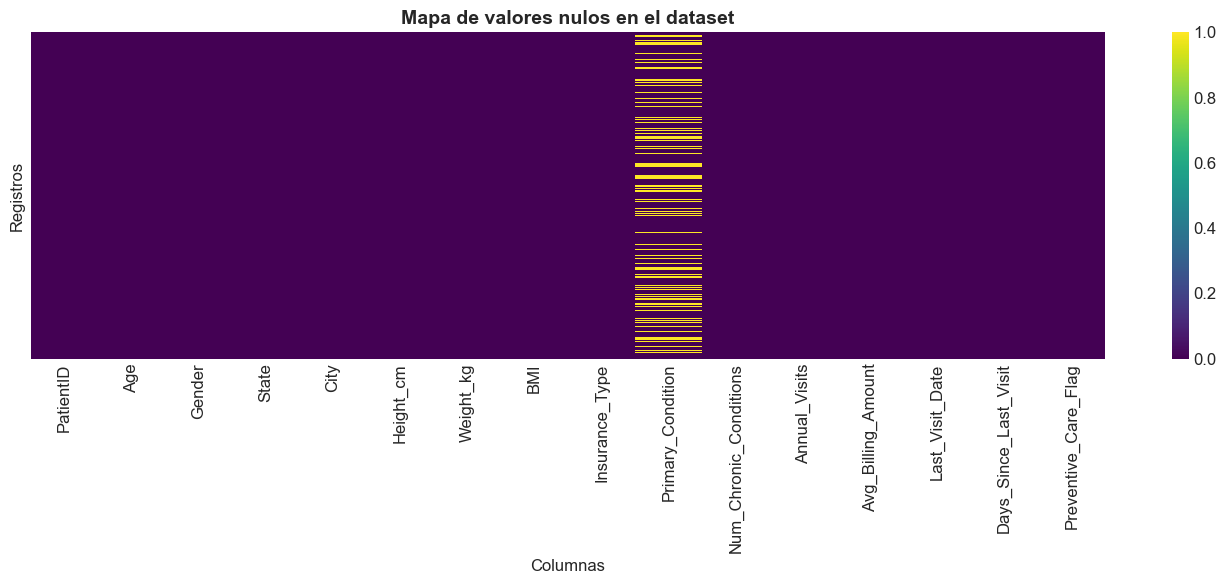

In [18]:
# Visualizacion de valores nulos con heatmap
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Mapa de valores nulos en el dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Columnas')
ax.set_ylabel('Registros')
plt.tight_layout()
plt.show()

---
## Seccion 3: Distribuciones univariadas

Analizamos la distribucion de cada variable de forma individual: histogramas para variables numericas y graficos de conteo para variables categoricas.

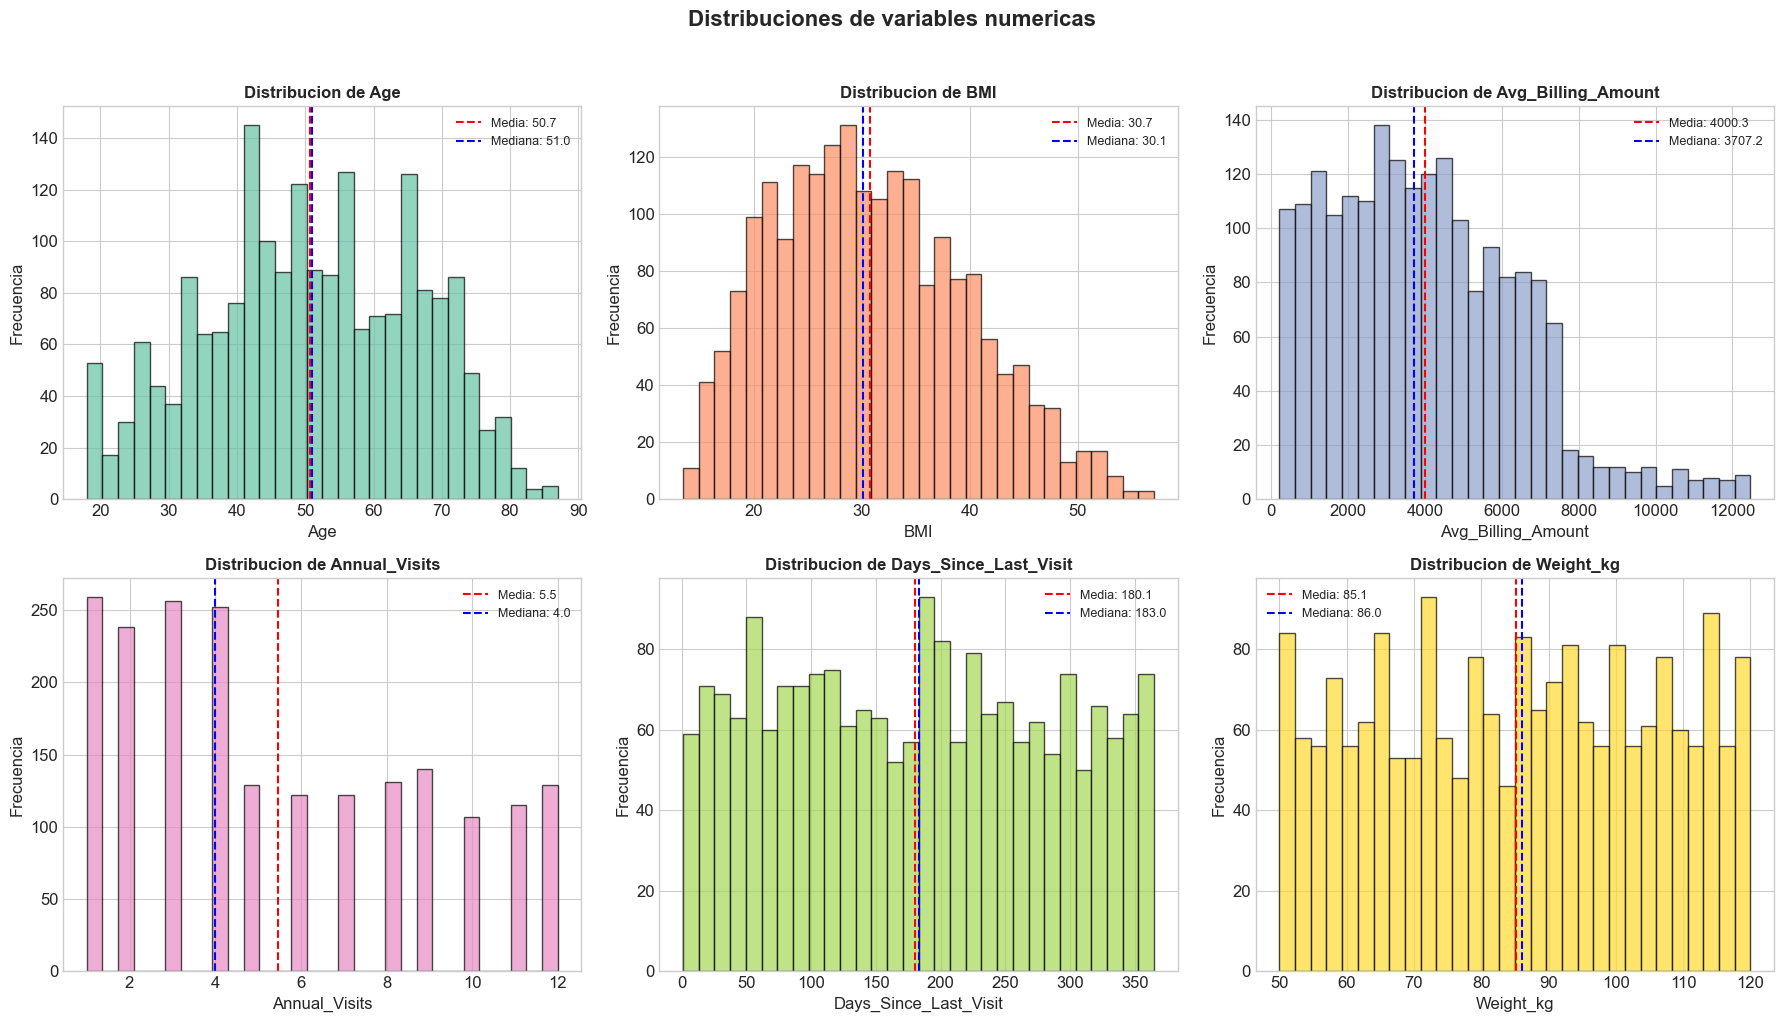

In [19]:
# Histogramas de variables numericas (grilla 2x3)
num_vars = ['Age', 'BMI', 'Avg_Billing_Amount', 'Annual_Visits', 'Days_Since_Last_Visit', 'Weight_kg']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    axes[i].hist(df[var].dropna(), bins=30, color=sns.color_palette('Set2')[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribucion de {var}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(df[var].mean(), color='red', linestyle='--', label=f'Media: {df[var].mean():.1f}')
    axes[i].axvline(df[var].median(), color='blue', linestyle='--', label=f'Mediana: {df[var].median():.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribuciones de variables numericas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

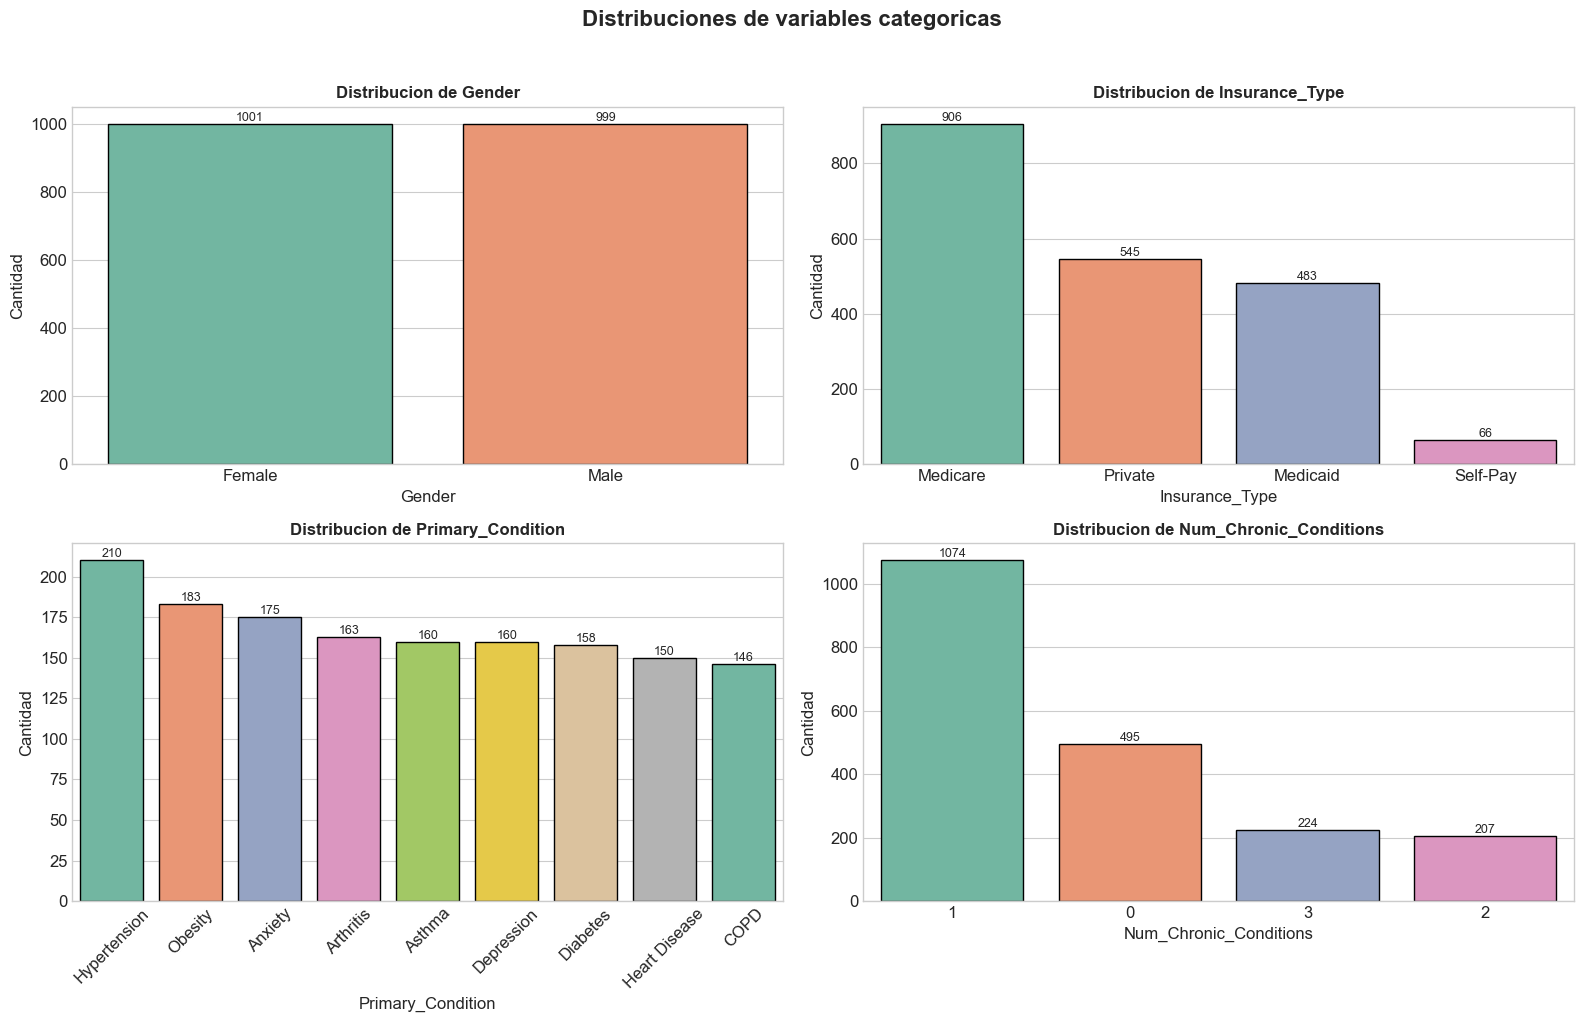

In [20]:
# Graficos de conteo para variables categoricas
cat_vars = ['Gender', 'Insurance_Type', 'Primary_Condition', 'Num_Chronic_Conditions']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    order = df[var].value_counts().index
    sns.countplot(data=df, x=var, ax=axes[i], palette='Set2', order=order, edgecolor='black')
    axes[i].set_title(f'Distribucion de {var}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Cantidad')
    # Agregar etiquetas de conteo
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=9)
    if var == 'Primary_Condition':
        axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribuciones de variables categoricas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

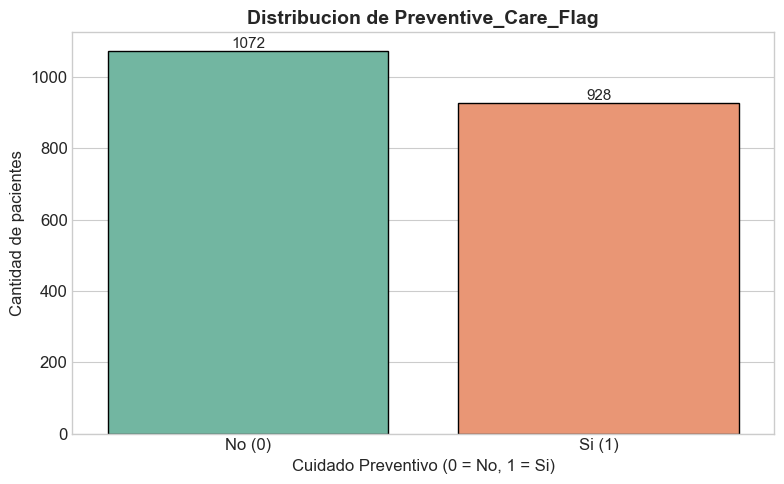

In [21]:
# Countplot de Preventive_Care_Flag
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Preventive_Care_Flag', palette='Set2', edgecolor='black', ax=ax)
ax.set_title('Distribucion de Preventive_Care_Flag', fontsize=14, fontweight='bold')
ax.set_xlabel('Cuidado Preventivo (0 = No, 1 = Si)')
ax.set_ylabel('Cantidad de pacientes')
ax.set_xticks([0, 1])
ax.set_xticklabels(['No (0)', 'Si (1)'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

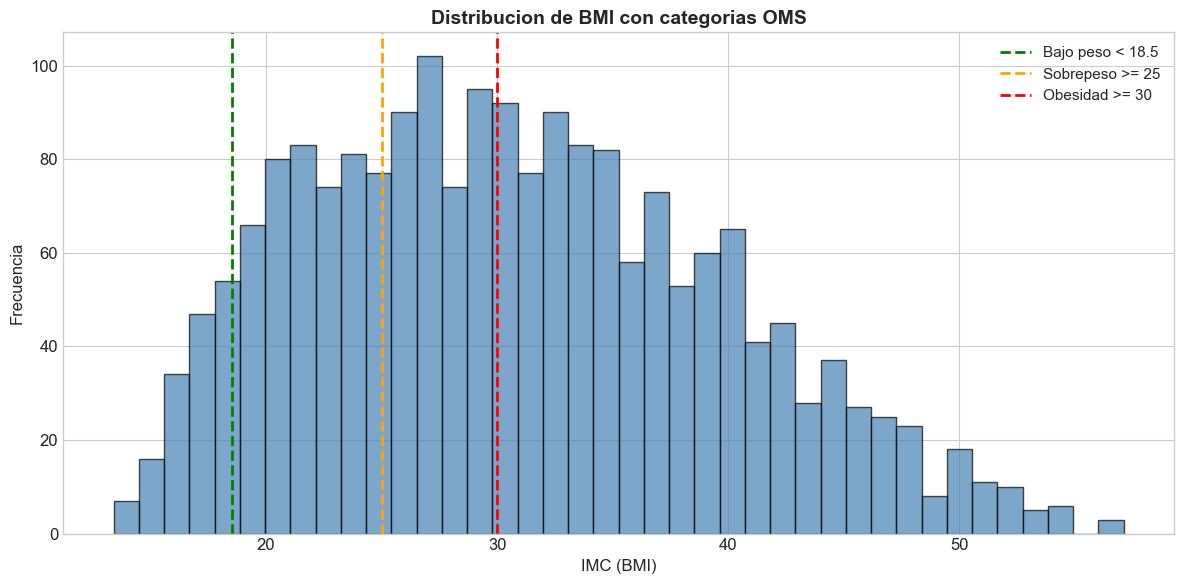

=== Categorias de BMI (OMS) ===
Bajo peso (BMI < 18.5): 135 pacientes (6.8%)
Normal (18.5 <= BMI < 25): 453 pacientes (22.7%)
Sobrepeso (25 <= BMI < 30): 404 pacientes (20.2%)
Obesidad (BMI >= 30): 1008 pacientes (50.4%)


In [22]:
# Distribucion de BMI con lineas de categorias OMS
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df['BMI'].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.7)

# Lineas verticales de categorias OMS
ax.axvline(18.5, color='green', linestyle='--', linewidth=2, label='Bajo peso < 18.5')
ax.axvline(25, color='orange', linestyle='--', linewidth=2, label='Sobrepeso >= 25')
ax.axvline(30, color='red', linestyle='--', linewidth=2, label='Obesidad >= 30')

ax.set_title('Distribucion de BMI con categorias OMS', fontsize=14, fontweight='bold')
ax.set_xlabel('IMC (BMI)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Resumen de categorias BMI
print('=== Categorias de BMI (OMS) ===')
print(f'Bajo peso (BMI < 18.5): {(df["BMI"] < 18.5).sum()} pacientes ({(df["BMI"] < 18.5).mean()*100:.1f}%)')
print(f'Normal (18.5 <= BMI < 25): {((df["BMI"] >= 18.5) & (df["BMI"] < 25)).sum()} pacientes ({((df["BMI"] >= 18.5) & (df["BMI"] < 25)).mean()*100:.1f}%)')
print(f'Sobrepeso (25 <= BMI < 30): {((df["BMI"] >= 25) & (df["BMI"] < 30)).sum()} pacientes ({((df["BMI"] >= 25) & (df["BMI"] < 30)).mean()*100:.1f}%)')
print(f'Obesidad (BMI >= 30): {(df["BMI"] >= 30).sum()} pacientes ({(df["BMI"] >= 30).mean()*100:.1f}%)')

---
## Seccion 4: Deteccion de outliers

Identificamos valores atipicos usando boxplots y el metodo del rango intercuartilico (IQR). Un valor se considera outlier si esta por debajo de Q1 - 1.5*IQR o por encima de Q3 + 1.5*IQR.

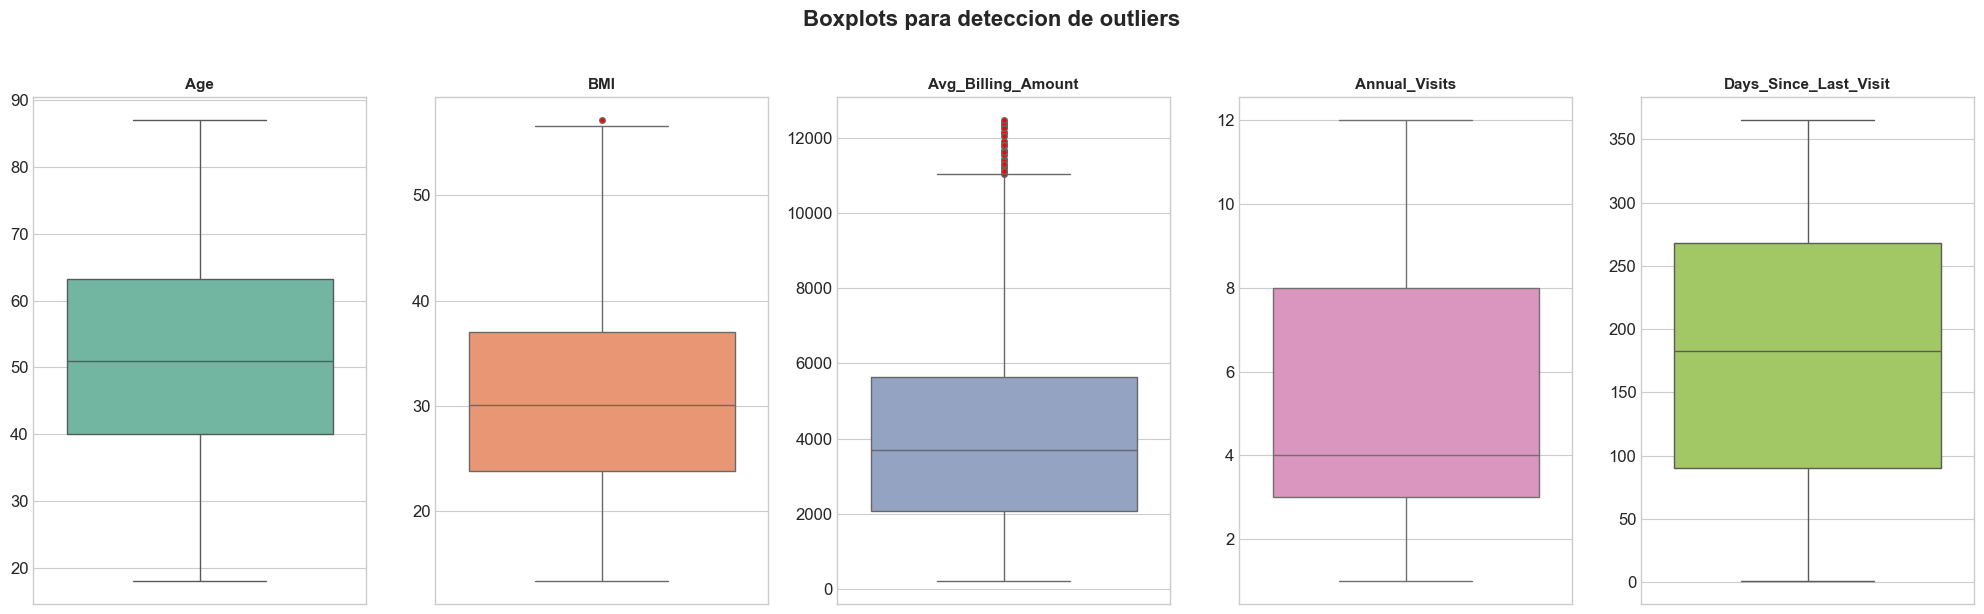

In [23]:
# Boxplots de variables numericas clave
outlier_vars = ['Age', 'BMI', 'Avg_Billing_Amount', 'Annual_Visits', 'Days_Since_Last_Visit']

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for i, var in enumerate(outlier_vars):
    sns.boxplot(data=df, y=var, ax=axes[i], color=sns.color_palette('Set2')[i],
                flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
    axes[i].set_title(f'{var}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('')

plt.suptitle('Boxplots para deteccion de outliers', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# Metodo IQR para contar outliers por variable
print('=== Deteccion de outliers con metodo IQR ===')
print(f'{"Variable":<25} {"Q1":>10} {"Q3":>10} {"IQR":>10} {"Lim. Inf":>10} {"Lim. Sup":>10} {"Outliers":>10} {"% Outliers":>10}')
print('-' * 95)

outlier_summary = []

for var in outlier_vars:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers = ((df[var] < lim_inf) | (df[var] > lim_sup)).sum()
    pct = (outliers / len(df) * 100)
    
    print(f'{var:<25} {Q1:>10.2f} {Q3:>10.2f} {IQR:>10.2f} {lim_inf:>10.2f} {lim_sup:>10.2f} {outliers:>10} {pct:>9.2f}%')
    outlier_summary.append({'Variable': var, 'Outliers': outliers, 'Porcentaje': f'{pct:.2f}%'})

print()
print('Resumen:')
pd.DataFrame(outlier_summary)

=== Deteccion de outliers con metodo IQR ===
Variable                          Q1         Q3        IQR   Lim. Inf   Lim. Sup   Outliers % Outliers
-----------------------------------------------------------------------------------------------
Age                            40.00      63.25      23.25       5.12      98.12          0      0.00%
BMI                            23.80      37.02      13.22       3.96      56.86          1      0.05%
Avg_Billing_Amount           2061.00    5650.88    3589.88   -3323.81   11035.69         28      1.40%
Annual_Visits                   3.00       8.00       5.00      -4.50      15.50          0      0.00%
Days_Since_Last_Visit          90.00     268.00     178.00    -177.00     535.00          0      0.00%

Resumen:


,Variable,Outliers,Porcentaje
0,Age,0,0.00%
1,BMI,1,0.05%
2,Avg_Billing_Amount,28,1.40%
3,Annual_Visits,0,0.00%
4,Days_Since_Last_Visit,0,0.00%


---
## Seccion 5: Analisis bivariado

Exploramos relaciones entre pares de variables para identificar patrones, diferencias entre grupos y posibles asociaciones.

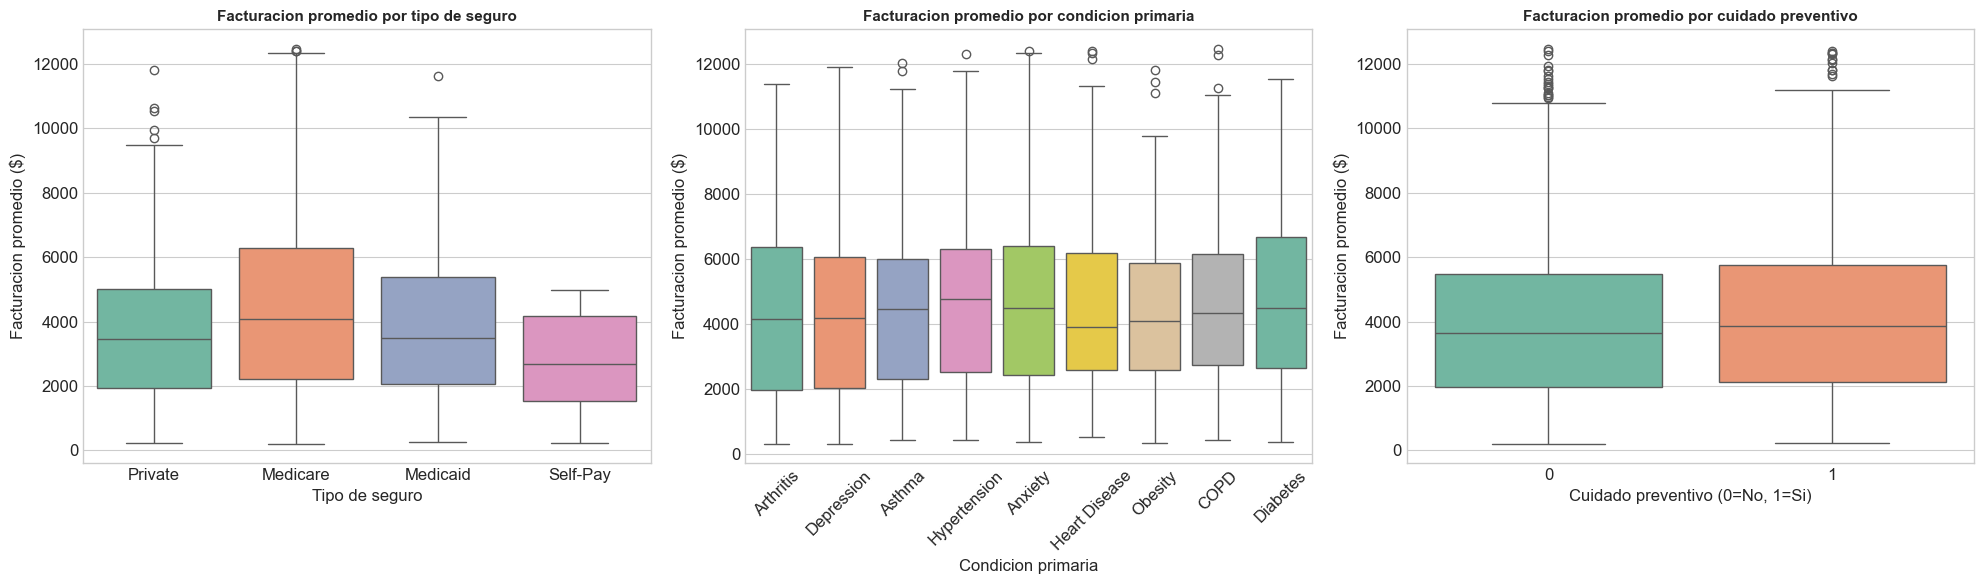

In [25]:
# Boxplots: Avg_Billing_Amount por Insurance_Type, Primary_Condition y Preventive_Care_Flag
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(data=df, x='Insurance_Type', y='Avg_Billing_Amount', palette='Set2', ax=axes[0])
axes[0].set_title('Facturacion promedio por tipo de seguro', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Tipo de seguro')
axes[0].set_ylabel('Facturacion promedio ($)')

sns.boxplot(data=df, x='Primary_Condition', y='Avg_Billing_Amount', palette='Set2', ax=axes[1])
axes[1].set_title('Facturacion promedio por condicion primaria', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Condicion primaria')
axes[1].set_ylabel('Facturacion promedio ($)')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='Preventive_Care_Flag', y='Avg_Billing_Amount', palette='Set2', ax=axes[2])
axes[2].set_title('Facturacion promedio por cuidado preventivo', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Cuidado preventivo (0=No, 1=Si)')
axes[2].set_ylabel('Facturacion promedio ($)')

plt.tight_layout()
plt.show()

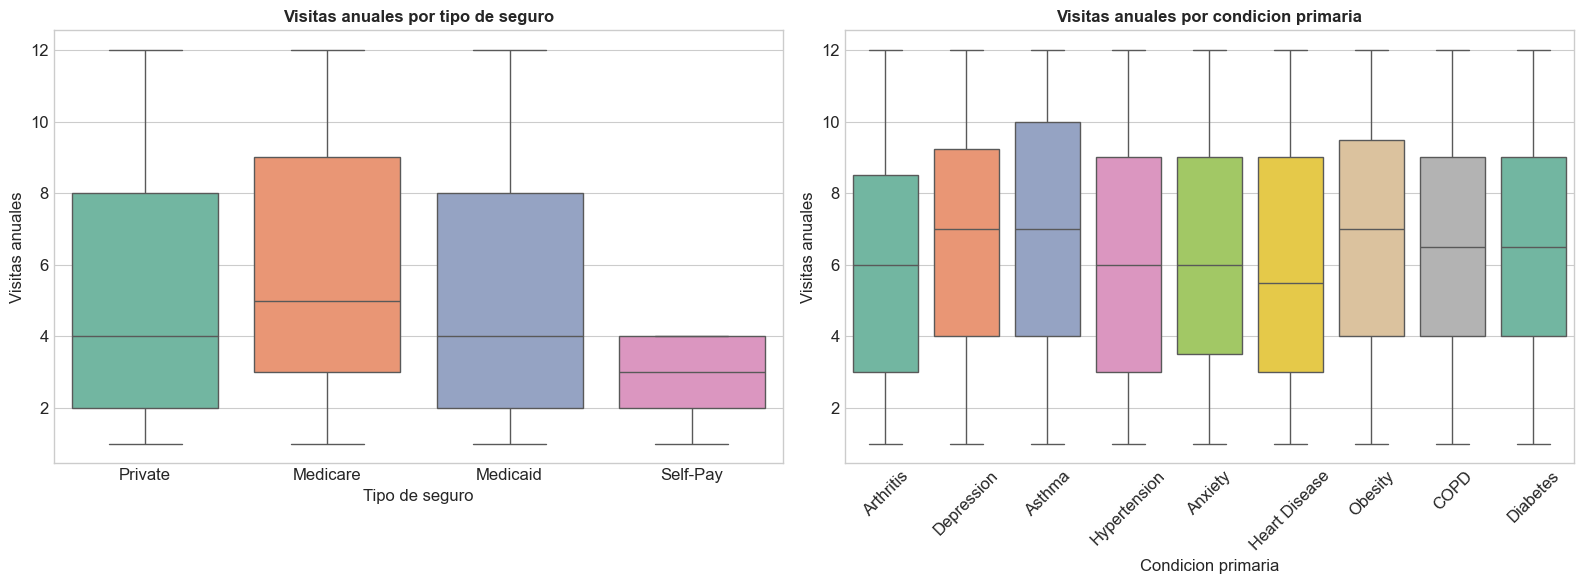

In [26]:
# Boxplots: Annual_Visits por Insurance_Type y Primary_Condition
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Insurance_Type', y='Annual_Visits', palette='Set2', ax=axes[0])
axes[0].set_title('Visitas anuales por tipo de seguro', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tipo de seguro')
axes[0].set_ylabel('Visitas anuales')

sns.boxplot(data=df, x='Primary_Condition', y='Annual_Visits', palette='Set2', ax=axes[1])
axes[1].set_title('Visitas anuales por condicion primaria', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Condicion primaria')
axes[1].set_ylabel('Visitas anuales')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

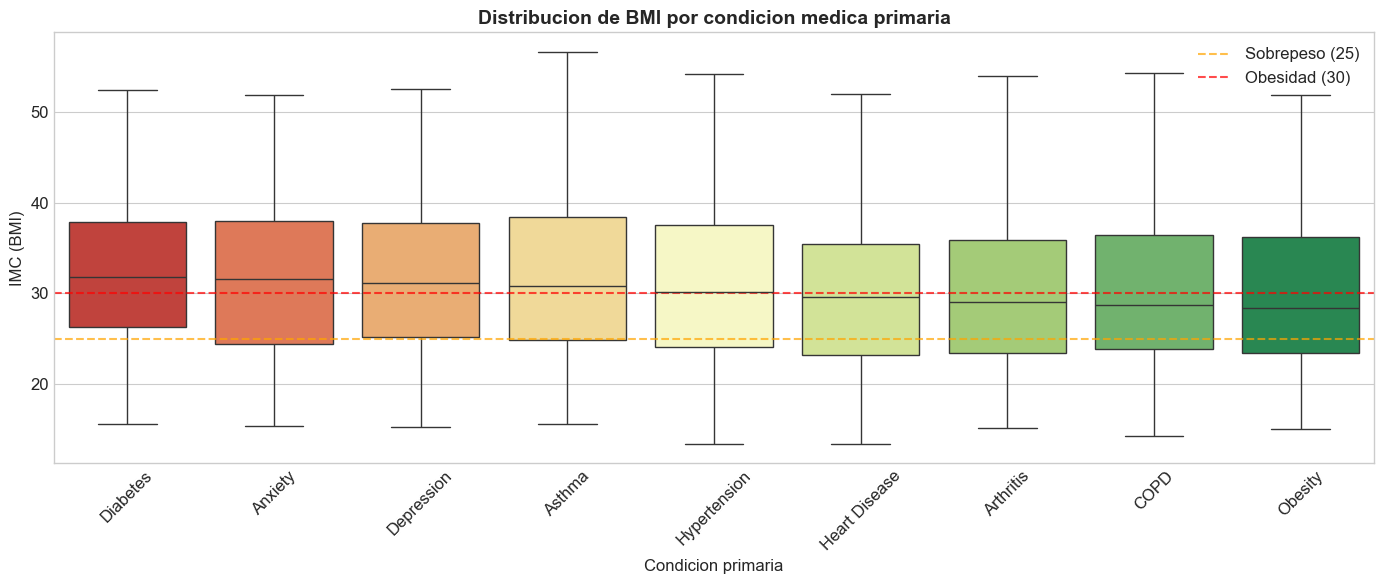

In [27]:
# Boxplot: BMI por Primary_Condition
fig, ax = plt.subplots(figsize=(14, 6))
order = df.groupby('Primary_Condition')['BMI'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Primary_Condition', y='BMI', palette='RdYlGn', order=order, ax=ax)
ax.set_title('Distribucion de BMI por condicion medica primaria', fontsize=14, fontweight='bold')
ax.set_xlabel('Condicion primaria')
ax.set_ylabel('IMC (BMI)')
ax.tick_params(axis='x', rotation=45)
ax.axhline(25, color='orange', linestyle='--', alpha=0.7, label='Sobrepeso (25)')
ax.axhline(30, color='red', linestyle='--', alpha=0.7, label='Obesidad (30)')
ax.legend()
plt.tight_layout()
plt.show()

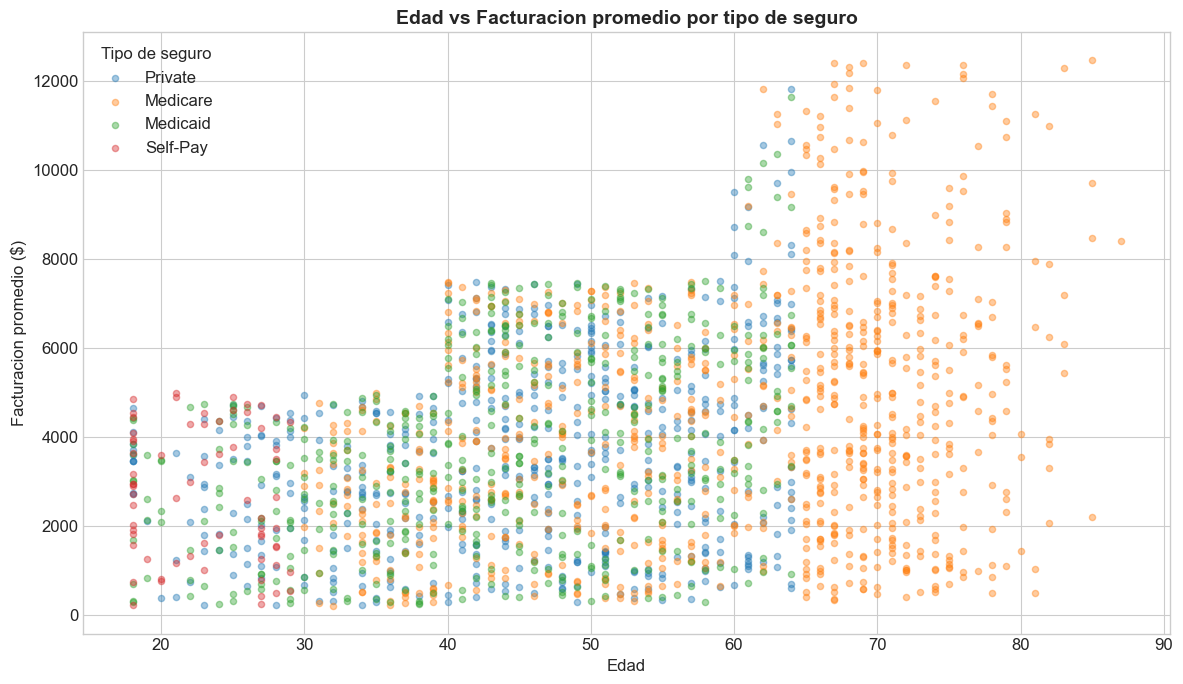

In [28]:
# Scatter: Age vs Avg_Billing_Amount coloreado por Insurance_Type
fig, ax = plt.subplots(figsize=(12, 7))
for ins_type in df['Insurance_Type'].unique():
    subset = df[df['Insurance_Type'] == ins_type]
    ax.scatter(subset['Age'], subset['Avg_Billing_Amount'], alpha=0.4, label=ins_type, s=20)

ax.set_title('Edad vs Facturacion promedio por tipo de seguro', fontsize=14, fontweight='bold')
ax.set_xlabel('Edad')
ax.set_ylabel('Facturacion promedio ($)')
ax.legend(title='Tipo de seguro')
plt.tight_layout()
plt.show()

In [29]:
# Scatter: BMI vs Num_Chronic_Conditions coloreado por Primary_Condition
fig = px.scatter(df, x='BMI', y='Num_Chronic_Conditions',
                 color='Primary_Condition',
                 title='BMI vs Numero de condiciones cronicas por condicion primaria',
                 labels={'BMI': 'IMC (BMI)', 'Num_Chronic_Conditions': 'Condiciones cronicas'},
                 opacity=0.5,
                 color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(width=900, height=550)
fig.show()

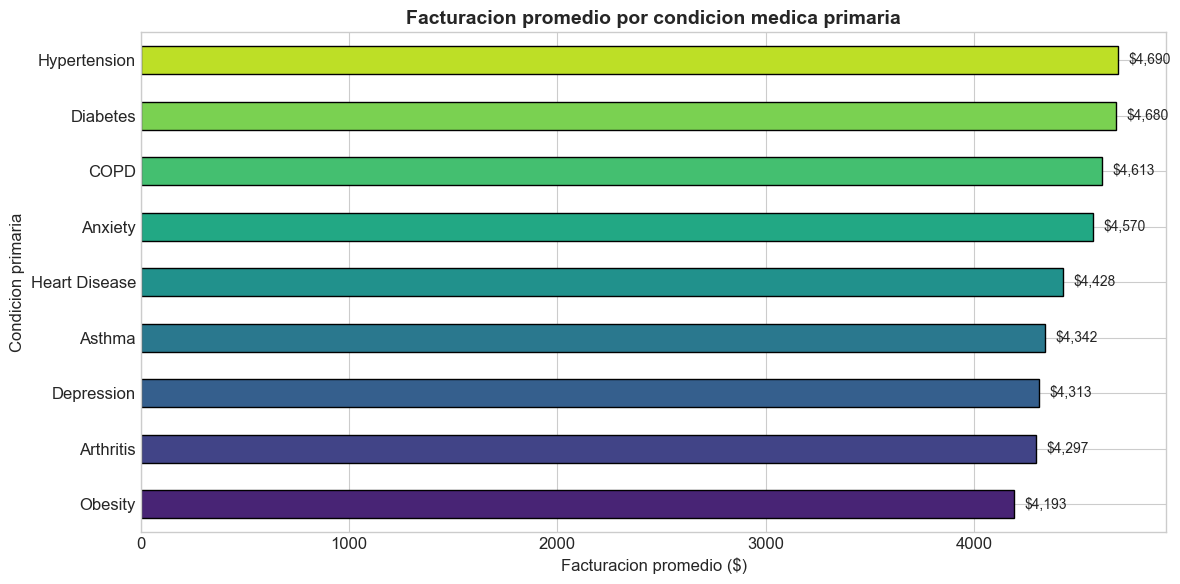

In [30]:
# Barplot: Facturacion promedio por condicion primaria (ordenado)
fig, ax = plt.subplots(figsize=(12, 6))
mean_billing = df.groupby('Primary_Condition')['Avg_Billing_Amount'].mean().sort_values(ascending=True)
mean_billing.plot(kind='barh', color=sns.color_palette('viridis', len(mean_billing)), edgecolor='black', ax=ax)
ax.set_title('Facturacion promedio por condicion medica primaria', fontsize=14, fontweight='bold')
ax.set_xlabel('Facturacion promedio ($)')
ax.set_ylabel('Condicion primaria')

# Agregar etiquetas de valor
for i, v in enumerate(mean_billing):
    ax.text(v + 50, i, f'${v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

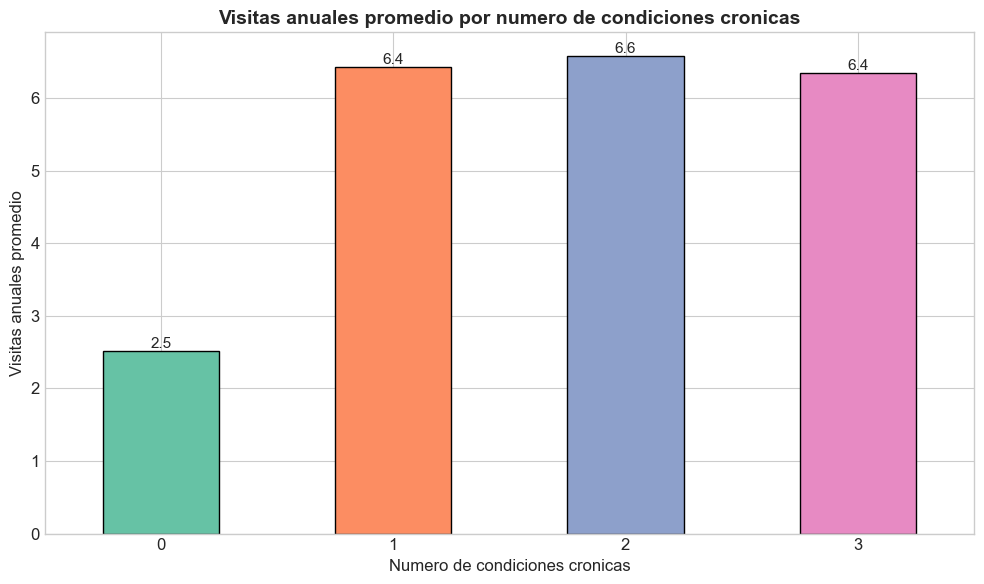

In [31]:
# Barplot: Visitas anuales promedio por numero de condiciones cronicas
fig, ax = plt.subplots(figsize=(10, 6))
mean_visits = df.groupby('Num_Chronic_Conditions')['Annual_Visits'].mean().sort_index()
mean_visits.plot(kind='bar', color=sns.color_palette('Set2', len(mean_visits)), edgecolor='black', ax=ax)
ax.set_title('Visitas anuales promedio por numero de condiciones cronicas', fontsize=14, fontweight='bold')
ax.set_xlabel('Numero de condiciones cronicas')
ax.set_ylabel('Visitas anuales promedio')
ax.tick_params(axis='x', rotation=0)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

---
## Seccion 6: Matriz de correlacion

Calculamos la correlacion de Pearson entre todas las variables numericas para identificar relaciones lineales significativas.

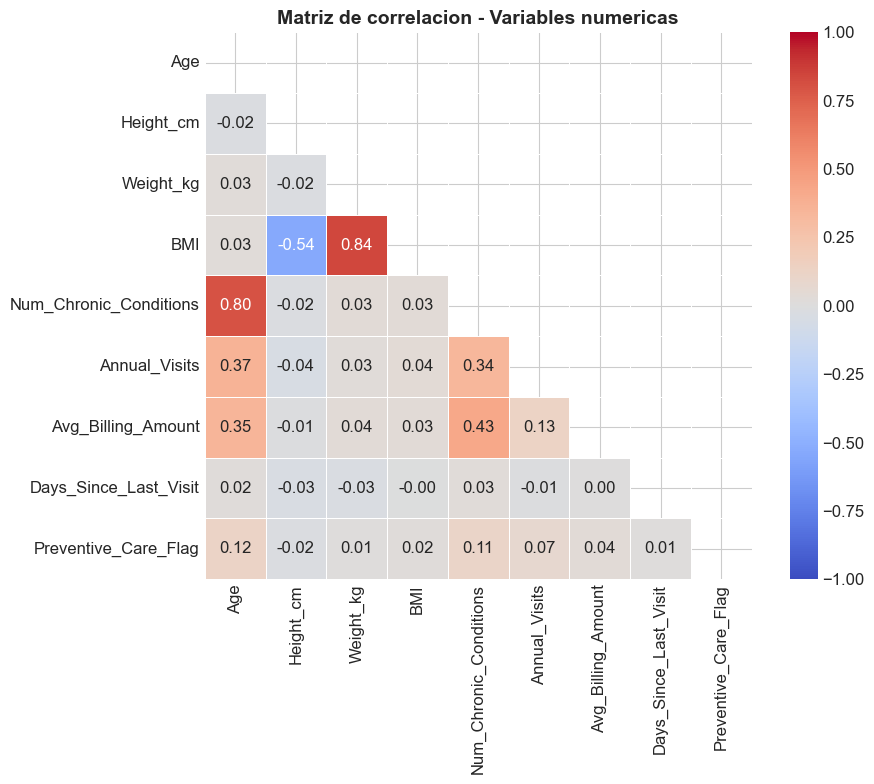

In [32]:
# Matriz de correlacion
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            square=True)
ax.set_title('Matriz de correlacion - Variables numericas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
# Identificar las correlaciones mas fuertes (excluyendo la diagonal)
print('=== Correlaciones mas fuertes ===')
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append({
            'Variable 1': corr_matrix.columns[i],
            'Variable 2': corr_matrix.columns[j],
            'Correlacion': corr_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs)
corr_df['Abs_Corr'] = corr_df['Correlacion'].abs()
corr_df = corr_df.sort_values('Abs_Corr', ascending=False).head(10)
print(corr_df[['Variable 1', 'Variable 2', 'Correlacion']].to_string(index=False))

=== Correlaciones mas fuertes ===
            Variable 1             Variable 2  Correlacion
             Weight_kg                    BMI     0.842057
                   Age Num_Chronic_Conditions     0.797068
             Height_cm                    BMI    -0.535225
Num_Chronic_Conditions     Avg_Billing_Amount     0.425172
                   Age          Annual_Visits     0.366565
                   Age     Avg_Billing_Amount     0.350142
Num_Chronic_Conditions          Annual_Visits     0.336860
         Annual_Visits     Avg_Billing_Amount     0.125944
                   Age   Preventive_Care_Flag     0.118994
Num_Chronic_Conditions   Preventive_Care_Flag     0.113472


---
## Seccion 7: Analisis por condicion medica

Profundizamos en como se distribuyen las diferentes condiciones medicas primarias y su relacion con facturacion, visitas y tipo de seguro.

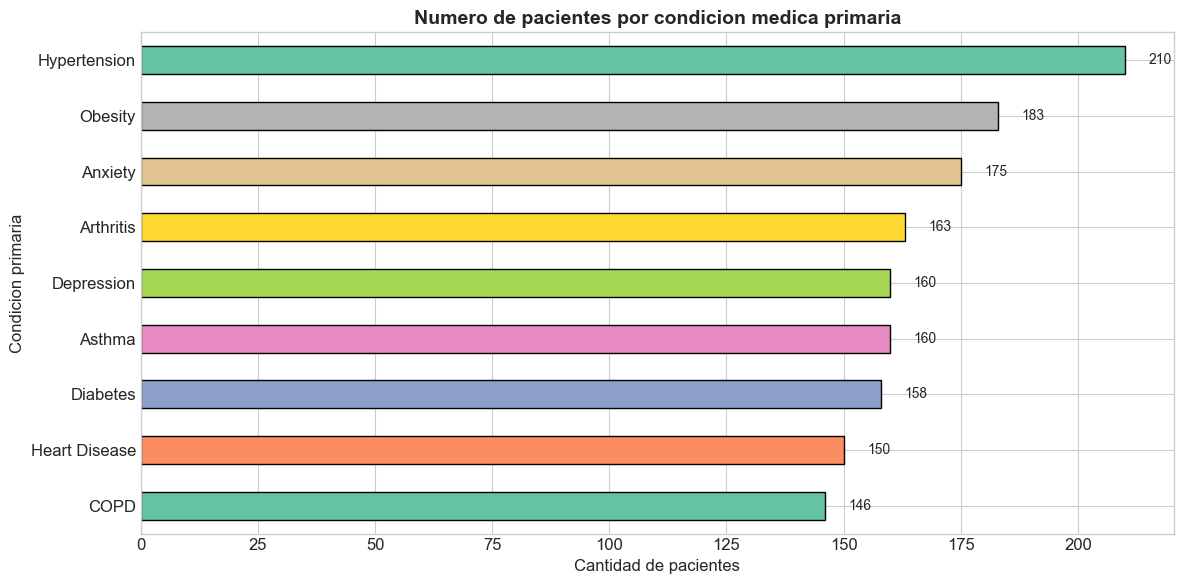

In [34]:
# Conteo de pacientes por condicion primaria (barplot horizontal)
fig, ax = plt.subplots(figsize=(12, 6))
condition_counts = df['Primary_Condition'].value_counts().sort_values()
condition_counts.plot(kind='barh', color=sns.color_palette('Set2', len(condition_counts)),
                      edgecolor='black', ax=ax)
ax.set_title('Numero de pacientes por condicion medica primaria', fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad de pacientes')
ax.set_ylabel('Condicion primaria')

for i, v in enumerate(condition_counts):
    ax.text(v + 5, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [35]:
# Metricas promedio por condicion medica
metrics_by_condition = df.groupby('Primary_Condition').agg(
    Facturacion_Promedio=('Avg_Billing_Amount', 'mean'),
    Visitas_Promedio=('Annual_Visits', 'mean'),
    Condiciones_Cronicas_Promedio=('Num_Chronic_Conditions', 'mean'),
    BMI_Promedio=('BMI', 'mean'),
    Edad_Promedio=('Age', 'mean'),
    Total_Pacientes=('PatientID', 'count')
).round(2).sort_values('Facturacion_Promedio', ascending=False)

print('=== Metricas promedio por condicion medica ===')
metrics_by_condition

=== Metricas promedio por condicion medica ===


,Facturacion_Promedio,Visitas_Promedio,Condiciones_Cronicas_Promedio,BMI_Promedio,Edad_Promedio,Total_Pacientes
Primary_Condition,,,,,,
Hypertension,4689.83,6.43,1.41,31.35,57.09,210
Diabetes,4679.84,6.58,1.43,31.85,56.37,158
COPD,4613.46,6.34,1.41,30.49,56.70,146
Anxiety,4569.71,6.38,1.47,31.65,58.80,175
Heart Disease,4428.27,5.89,1.47,30.14,58.35,150
Asthma,4341.62,6.91,1.41,32.00,57.24,160
Depression,4313.03,6.71,1.41,31.64,57.62,160
Arthritis,4297.17,6.00,1.42,30.21,56.45,163
Obesity,4193.49,6.65,1.48,29.81,57.62,183


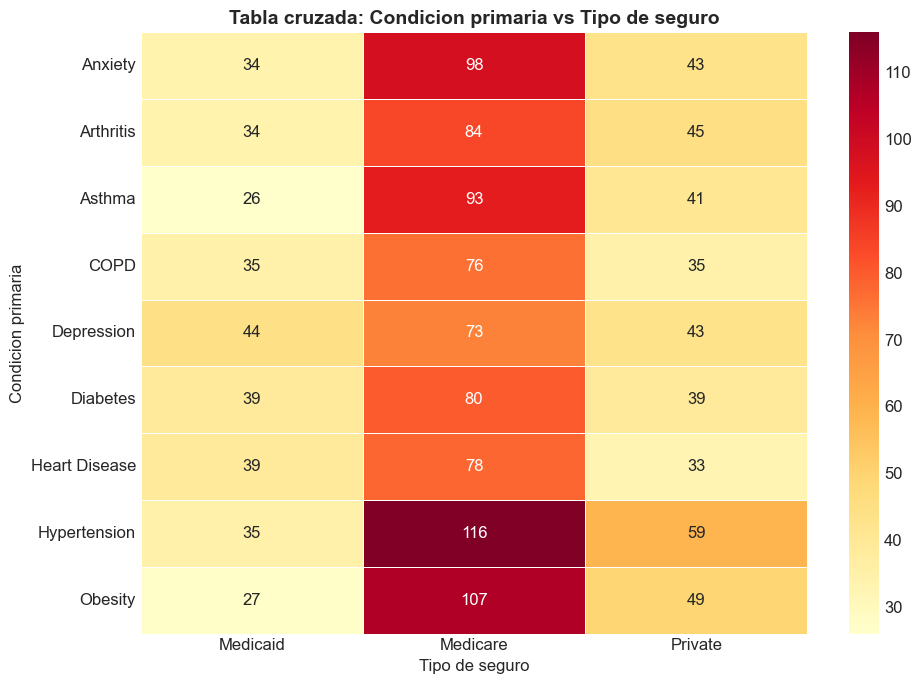

In [36]:
# Crosstab: Primary_Condition vs Insurance_Type (heatmap)
ct = pd.crosstab(df['Primary_Condition'], df['Insurance_Type'])

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Tabla cruzada: Condicion primaria vs Tipo de seguro', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de seguro')
ax.set_ylabel('Condicion primaria')
plt.tight_layout()
plt.show()

=== Porcentaje de cuidado preventivo por condicion medica ===
                   Sin cuidado preventivo (%)  Con cuidado preventivo (%)
Primary_Condition                                                        
Anxiety                                 46.29                       53.71
Arthritis                               46.01                       53.99
Asthma                                  53.12                       46.88
COPD                                    48.63                       51.37
Depression                              51.88                       48.12
Diabetes                                55.06                       44.94
Heart Disease                           50.67                       49.33
Hypertension                            51.90                       48.10
Obesity                                 45.36                       54.64



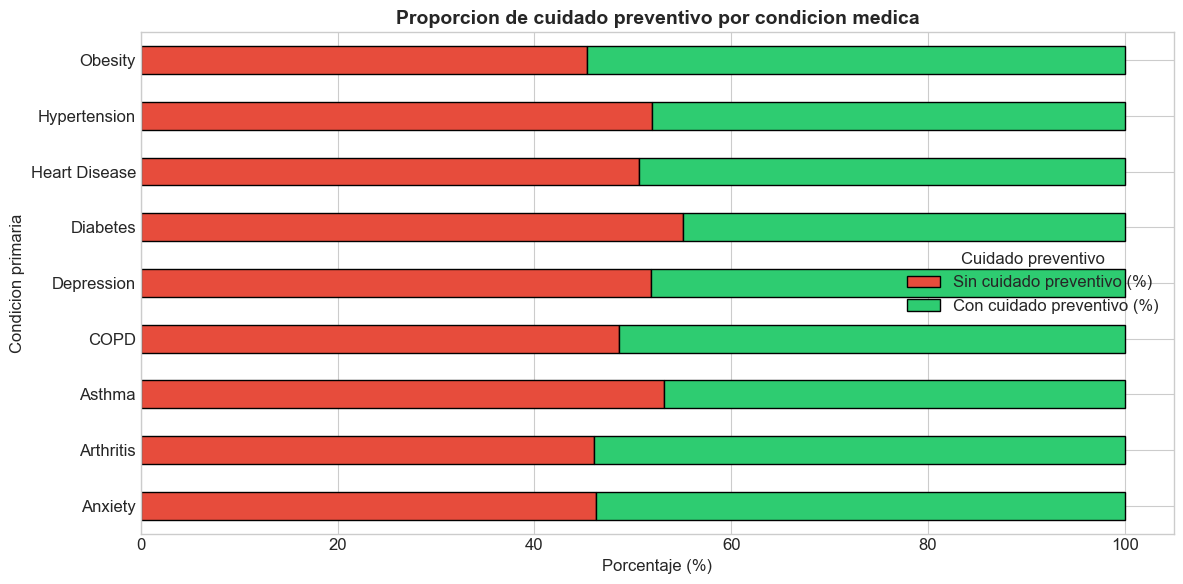

In [37]:
# Crosstab: Primary_Condition vs Preventive_Care_Flag (porcentaje)
ct_prev = pd.crosstab(df['Primary_Condition'], df['Preventive_Care_Flag'], normalize='index') * 100
ct_prev.columns = ['Sin cuidado preventivo (%)', 'Con cuidado preventivo (%)']

print('=== Porcentaje de cuidado preventivo por condicion medica ===')
print(ct_prev.round(2).to_string())
print()

# Visualizar
fig, ax = plt.subplots(figsize=(12, 6))
ct_prev.plot(kind='barh', stacked=True, color=['#e74c3c', '#2ecc71'], edgecolor='black', ax=ax)
ax.set_title('Proporcion de cuidado preventivo por condicion medica', fontsize=14, fontweight='bold')
ax.set_xlabel('Porcentaje (%)')
ax.set_ylabel('Condicion primaria')
ax.legend(title='Cuidado preventivo')
plt.tight_layout()
plt.show()

---
## Seccion 8: Analisis de seguro y costos

Analizamos las diferencias en facturacion, frecuencia de visitas y comportamiento segun el tipo de seguro de los pacientes.

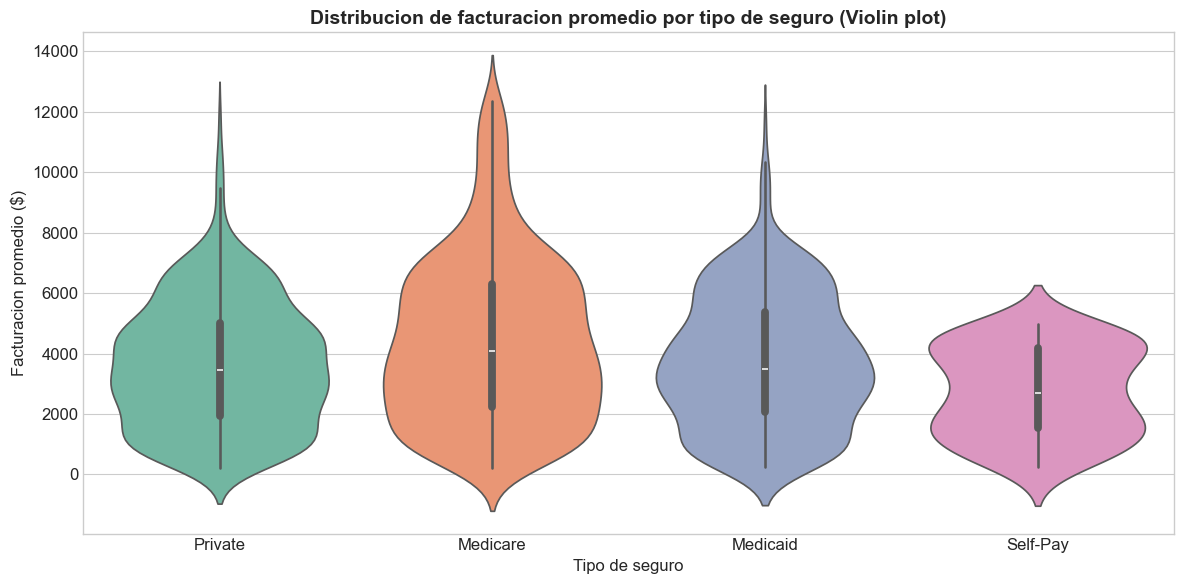

In [38]:
# Violin plot: Avg_Billing_Amount por Insurance_Type
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=df, x='Insurance_Type', y='Avg_Billing_Amount', palette='Set2',
               inner='box', ax=ax)
ax.set_title('Distribucion de facturacion promedio por tipo de seguro (Violin plot)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de seguro')
ax.set_ylabel('Facturacion promedio ($)')
plt.tight_layout()
plt.show()

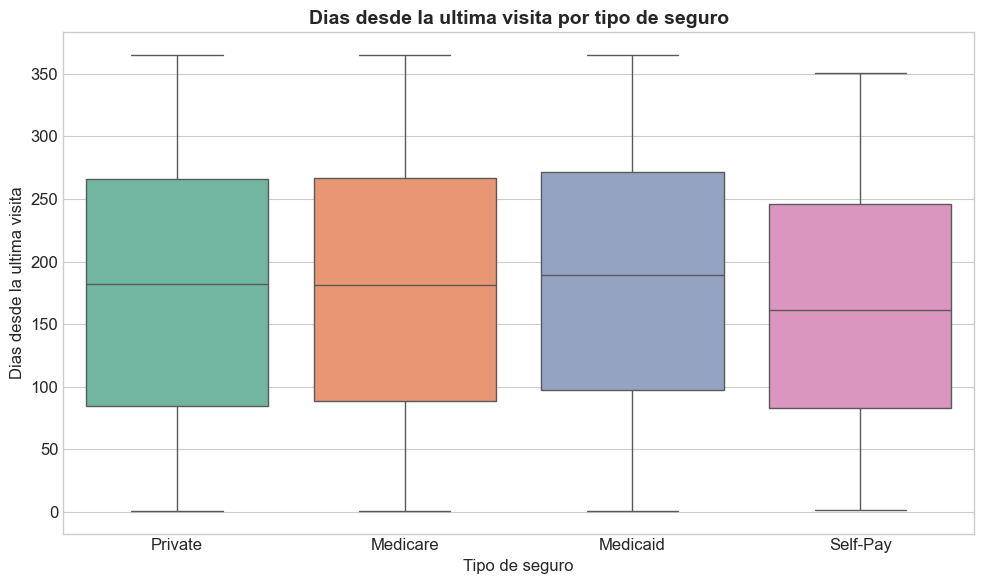

In [39]:
# Boxplot: Days_Since_Last_Visit por Insurance_Type
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='Insurance_Type', y='Days_Since_Last_Visit', palette='Set2', ax=ax)
ax.set_title('Dias desde la ultima visita por tipo de seguro', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de seguro')
ax.set_ylabel('Dias desde la ultima visita')
plt.tight_layout()
plt.show()

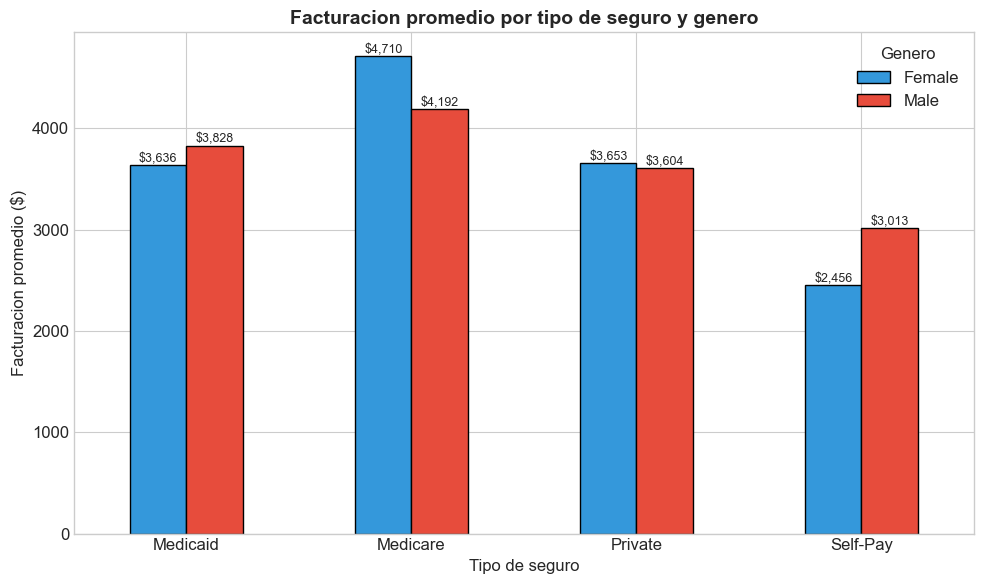

In [40]:
# Barplot: Facturacion promedio por tipo de seguro y genero
fig, ax = plt.subplots(figsize=(10, 6))
billing_by_ins_gender = df.groupby(['Insurance_Type', 'Gender'])['Avg_Billing_Amount'].mean().unstack()
billing_by_ins_gender.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], edgecolor='black')
ax.set_title('Facturacion promedio por tipo de seguro y genero', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de seguro')
ax.set_ylabel('Facturacion promedio ($)')
ax.legend(title='Genero')
ax.tick_params(axis='x', rotation=0)

for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

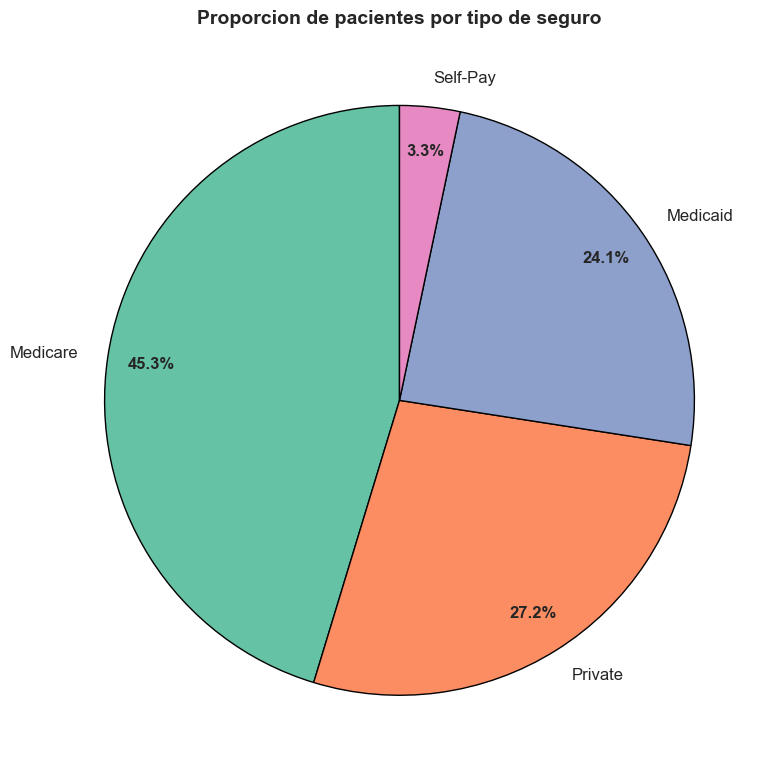

Conteo por tipo de seguro:
Insurance_Type
Medicare    906
Private     545
Medicaid    483
Self-Pay     66
Name: count, dtype: int64


In [41]:
# Grafico de torta: Proporcion de cada tipo de seguro
fig, ax = plt.subplots(figsize=(8, 8))
insurance_counts = df['Insurance_Type'].value_counts()
colors = sns.color_palette('Set2', len(insurance_counts))
wedges, texts, autotexts = ax.pie(insurance_counts, labels=insurance_counts.index,
                                   autopct='%1.1f%%', colors=colors,
                                   startangle=90, pctdistance=0.85,
                                   wedgeprops=dict(edgecolor='black', linewidth=1))

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

ax.set_title('Proporcion de pacientes por tipo de seguro', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Conteo por tipo de seguro:')
print(insurance_counts)

---
## Seccion 9: Prevencion y comportamiento

Comparamos el comportamiento de pacientes que utilizan cuidado preventivo vs los que no, analizando facturacion, frecuencia de visitas e inactividad.

=== Metricas por cuidado preventivo ===
                        Facturacion_Promedio  Visitas_Promedio  \
Sin cuidado preventivo               3917.07              5.23   
Con cuidado preventivo               4096.38              5.74   

                        Dias_Desde_Ultima_Visita  
Sin cuidado preventivo                    178.64  
Con cuidado preventivo                    181.75  


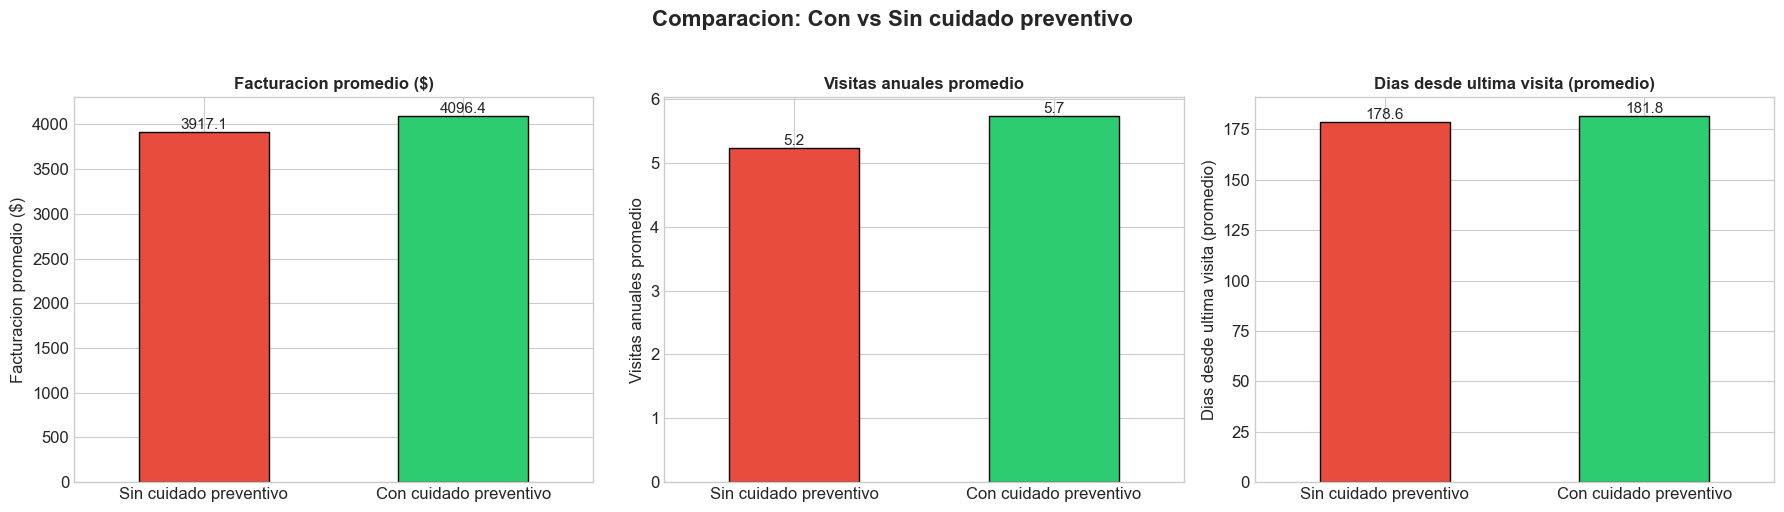

In [42]:
# Comparacion de metricas: Preventive_Care_Flag = 0 vs 1
prev_metrics = df.groupby('Preventive_Care_Flag').agg(
    Facturacion_Promedio=('Avg_Billing_Amount', 'mean'),
    Visitas_Promedio=('Annual_Visits', 'mean'),
    Dias_Desde_Ultima_Visita=('Days_Since_Last_Visit', 'mean')
).round(2)
prev_metrics.index = ['Sin cuidado preventivo', 'Con cuidado preventivo']
print('=== Metricas por cuidado preventivo ===')
print(prev_metrics)

# Barplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['Facturacion_Promedio', 'Visitas_Promedio', 'Dias_Desde_Ultima_Visita']
titles = ['Facturacion promedio ($)', 'Visitas anuales promedio', 'Dias desde ultima visita (promedio)']
colors_prev = ['#e74c3c', '#2ecc71']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    prev_metrics[metric].plot(kind='bar', ax=axes[i], color=colors_prev, edgecolor='black')
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_ylabel(title)
    axes[i].tick_params(axis='x', rotation=0)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.1f}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=11)

plt.suptitle('Comparacion: Con vs Sin cuidado preventivo', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

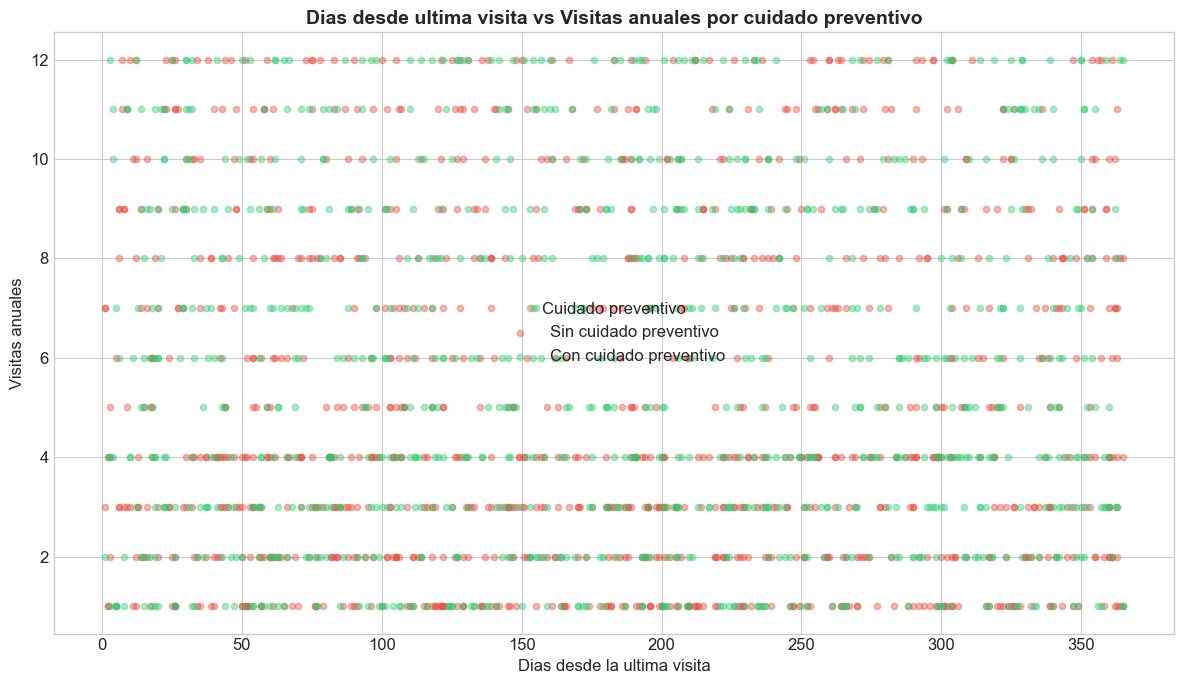

In [43]:
# Scatter: Days_Since_Last_Visit vs Annual_Visits coloreado por Preventive_Care_Flag
fig, ax = plt.subplots(figsize=(12, 7))
colors_map = {0: '#e74c3c', 1: '#2ecc71'}
labels_map = {0: 'Sin cuidado preventivo', 1: 'Con cuidado preventivo'}

for flag in [0, 1]:
    subset = df[df['Preventive_Care_Flag'] == flag]
    ax.scatter(subset['Days_Since_Last_Visit'], subset['Annual_Visits'],
              alpha=0.4, c=colors_map[flag], label=labels_map[flag], s=20)

ax.set_title('Dias desde ultima visita vs Visitas anuales por cuidado preventivo',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Dias desde la ultima visita')
ax.set_ylabel('Visitas anuales')
ax.legend(title='Cuidado preventivo')
plt.tight_layout()
plt.show()

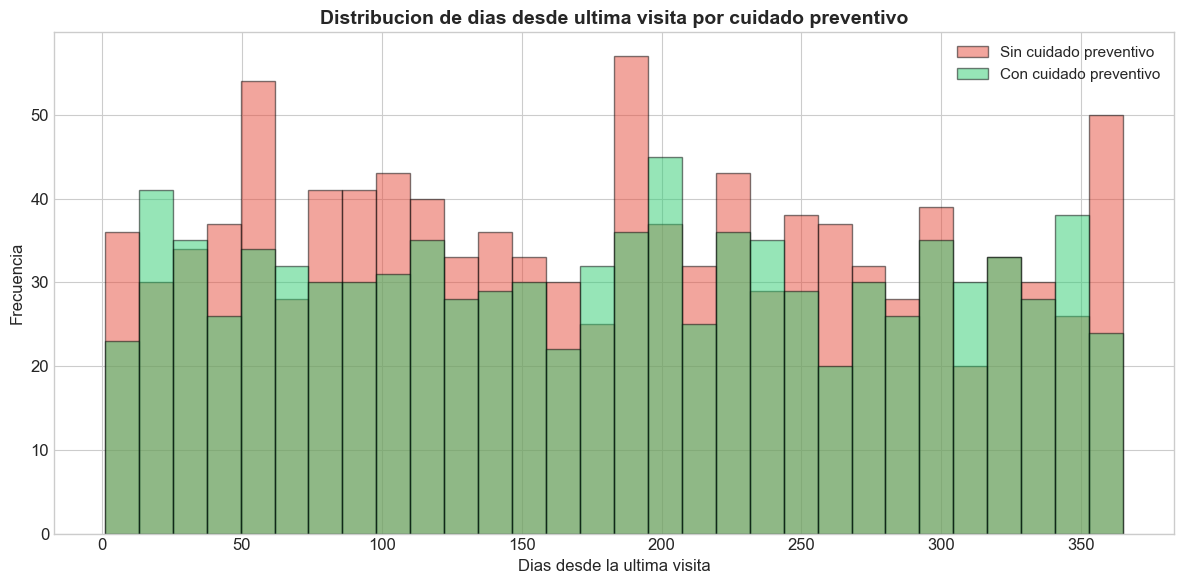

In [44]:
# Histogramas superpuestos: Days_Since_Last_Visit por Preventive_Care_Flag
fig, ax = plt.subplots(figsize=(12, 6))

for flag, color, label in [(0, '#e74c3c', 'Sin cuidado preventivo'),
                            (1, '#2ecc71', 'Con cuidado preventivo')]:
    subset = df[df['Preventive_Care_Flag'] == flag]['Days_Since_Last_Visit']
    ax.hist(subset, bins=30, alpha=0.5, color=color, label=label, edgecolor='black')

ax.set_title('Distribucion de dias desde ultima visita por cuidado preventivo',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Dias desde la ultima visita')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

=== Pacientes inactivos (> 180 dias desde ultima visita) ===
Total inactivos: 1013 (50.6%)
Total activos: 987 (49.4%)

Proporcion de inactividad por cuidado preventivo:
                        Activo (%)  Inactivo (%)
Sin cuidado preventivo       49.81         50.19
Con cuidado preventivo       48.81         51.19


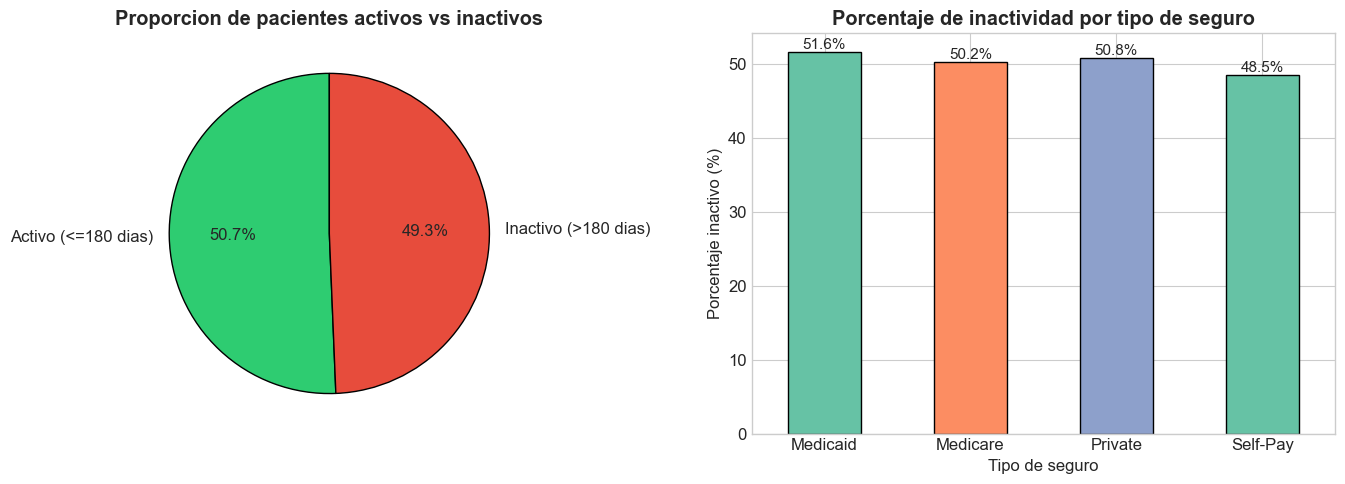

In [45]:
# Crear Inactivity_Flag (Days_Since_Last_Visit > 180) y analizar proporciones
df['Inactivity_Flag'] = (df['Days_Since_Last_Visit'] > 180).astype(int)

print('=== Pacientes inactivos (> 180 dias desde ultima visita) ===')
print(f'Total inactivos: {df["Inactivity_Flag"].sum()} ({df["Inactivity_Flag"].mean()*100:.1f}%)')
print(f'Total activos: {(df["Inactivity_Flag"] == 0).sum()} ({(df["Inactivity_Flag"] == 0).mean()*100:.1f}%)')
print()

# Proporcion de inactividad por cuidado preventivo
inact_by_prev = pd.crosstab(df['Preventive_Care_Flag'], df['Inactivity_Flag'], normalize='index') * 100
inact_by_prev.columns = ['Activo (%)', 'Inactivo (%)']
inact_by_prev.index = ['Sin cuidado preventivo', 'Con cuidado preventivo']
print('Proporcion de inactividad por cuidado preventivo:')
print(inact_by_prev.round(2))

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Proporcion general
df['Inactivity_Flag'].value_counts().plot(kind='pie', ax=axes[0],
    labels=['Activo (<=180 dias)', 'Inactivo (>180 dias)'],
    colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
    startangle=90, wedgeprops=dict(edgecolor='black'))
axes[0].set_title('Proporcion de pacientes activos vs inactivos', fontweight='bold')
axes[0].set_ylabel('')

# Grafico 2: Inactividad por tipo de seguro
inact_by_ins = df.groupby('Insurance_Type')['Inactivity_Flag'].mean() * 100
inact_by_ins.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2', 3), edgecolor='black')
axes[1].set_title('Porcentaje de inactividad por tipo de seguro', fontweight='bold')
axes[1].set_xlabel('Tipo de seguro')
axes[1].set_ylabel('Porcentaje inactivo (%)')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

---
## Seccion 10: Analisis demografico

Exploramos las distribuciones de edad y BMI por genero, creamos grupos etarios y analizamos su relacion con las condiciones medicas.

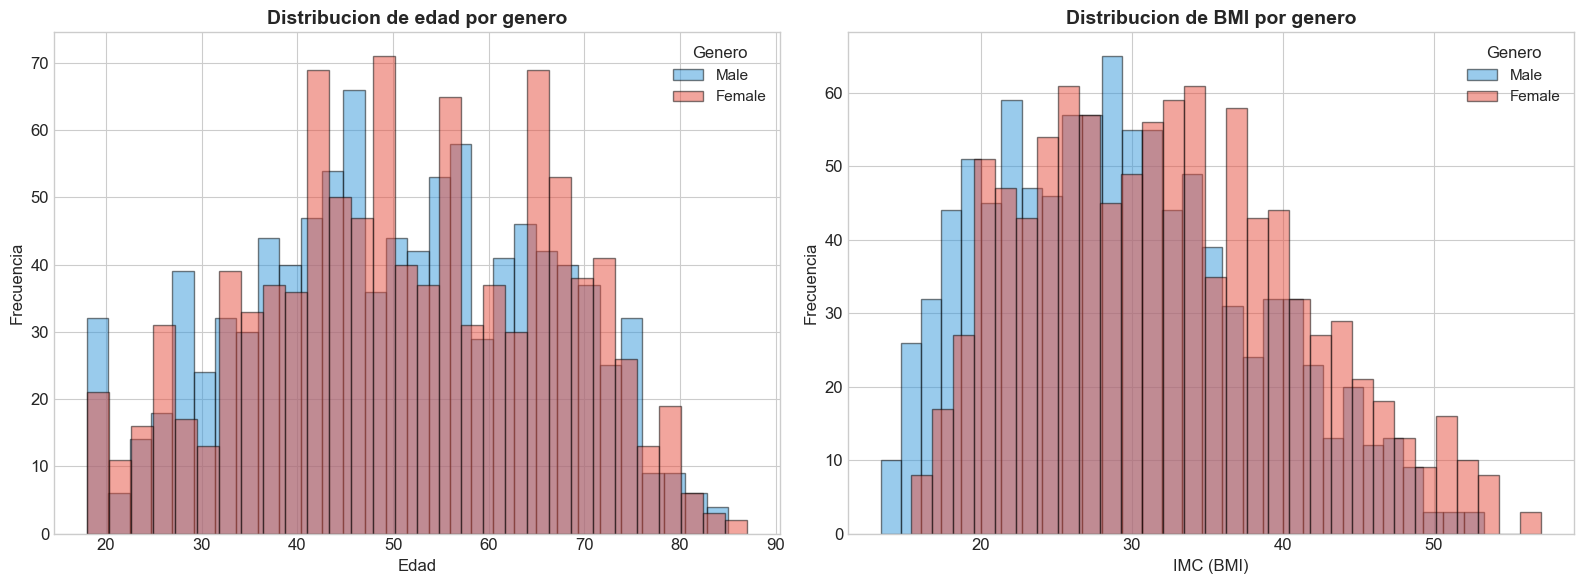

In [46]:
# Distribucion de edad por genero (histogramas superpuestos)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for gender, color in [('Male', '#3498db'), ('Female', '#e74c3c')]:
    subset = df[df['Gender'] == gender]['Age']
    axes[0].hist(subset, bins=30, alpha=0.5, color=color, label=gender, edgecolor='black')

axes[0].set_title('Distribucion de edad por genero', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(title='Genero', fontsize=11)

# Distribucion de BMI por genero
for gender, color in [('Male', '#3498db'), ('Female', '#e74c3c')]:
    subset = df[df['Gender'] == gender]['BMI']
    axes[1].hist(subset, bins=30, alpha=0.5, color=color, label=gender, edgecolor='black')

axes[1].set_title('Distribucion de BMI por genero', fontsize=14, fontweight='bold')
axes[1].set_xlabel('IMC (BMI)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(title='Genero', fontsize=11)

plt.tight_layout()
plt.show()

=== Distribucion por grupo de edad ===
Age_Group
18-30    227
31-45    551
46-60    613
60+      609
Name: count, dtype: int64



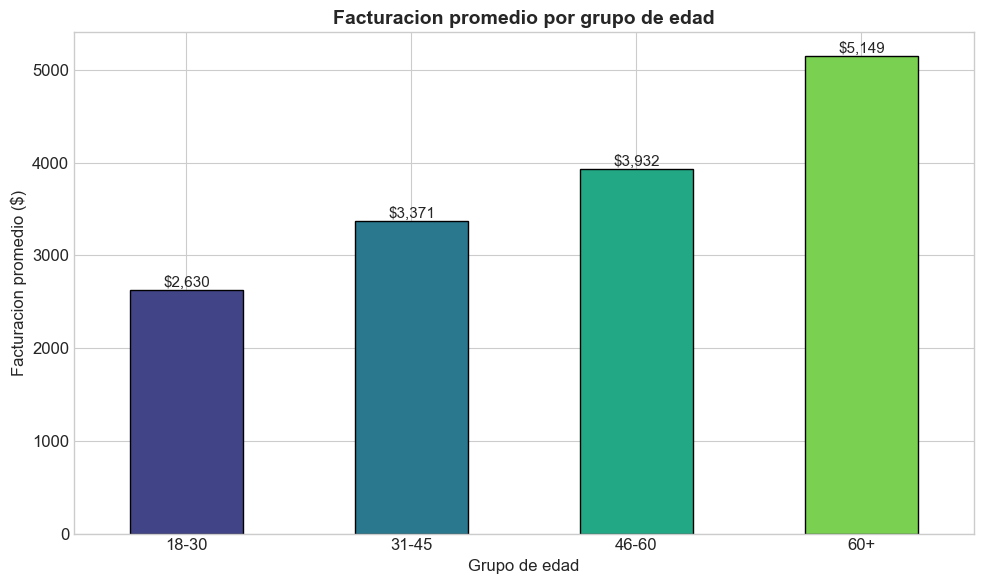

In [47]:
# Crear grupos de edad
bins = [0, 30, 45, 60, 120]
labels = ['18-30', '31-45', '46-60', '60+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

print('=== Distribucion por grupo de edad ===')
print(df['Age_Group'].value_counts().sort_index())
print()

# Barplot: Facturacion promedio por grupo de edad
fig, ax = plt.subplots(figsize=(10, 6))
mean_billing_age = df.groupby('Age_Group', observed=True)['Avg_Billing_Amount'].mean().sort_index()
mean_billing_age.plot(kind='bar', color=sns.color_palette('viridis', len(mean_billing_age)),
                      edgecolor='black', ax=ax)
ax.set_title('Facturacion promedio por grupo de edad', fontsize=14, fontweight='bold')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Facturacion promedio ($)')
ax.tick_params(axis='x', rotation=0)

for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

---
## Seccion 11: Conclusiones preliminares

### Hallazgos clave del Analisis Exploratorio

**1. Estructura y calidad de los datos:**
- El dataset contiene **2,000 pacientes** y **16 variables**. No hay duplicados.
- **495 nulos** en `Primary_Condition` (24.75%) — corresponden exactamente a los pacientes con `Num_Chronic_Conditions = 0`. Es decir, si no tienen condicion cronica, el campo queda vacio. Esto es consistente y no es un error.
- `City` tiene **50.6% de valores "Unknown"**, limitando analisis geograficos. `State` no tiene unknowns.
- Genero perfectamente balanceado (1001 F / 999 M) — posible dato sintetico.

**2. Tipo de seguro:**
- La mayoria de pacientes tiene **Medicare (45.3%)**, seguido de **Private (27.3%)** y **Medicaid (24.2%)**. Solo 66 pacientes (3.3%) son Self-Pay.
- Medicare tiene la **facturacion mas alta** ($4,458 promedio), seguido de Medicaid ($3,735), Private ($3,628) y Self-Pay ($2,726).
- Dato interesante: los pacientes **privados no pagan mas** que Medicare — posiblemente porque Medicare cubre pacientes mayores con mas cronicidad.

**3. Cronicidad — LA RELACION MAS FUERTE DEL DATASET:**
- Existe una relacion clara y progresiva entre `Num_Chronic_Conditions` y facturacion:
  - 0 condiciones: $2,598 promedio
  - 1 condicion: $3,999
  - 2 condiciones: $5,058
  - 3 condiciones: $6,124
- La correlacion `Age <-> Num_Chronic_Conditions` es **0.80** — la segunda mas alta del dataset. A mayor edad, mas condiciones cronicas.
- `Num_Chronic_Conditions <-> Avg_Billing_Amount` tiene correlacion **0.43** — la relacion predictiva mas util.

**4. Condiciones medicas:**
- Las condiciones mas frecuentes son: Hypertension (210), Obesity (183), Anxiety (175).
- Las mas costosas: **Hypertension ($4,690)** y **Diabetes ($4,680)**.
- Curiosamente, **Obesity tiene el BMI mas bajo** entre las condiciones (29.8 vs ~31 del resto). Esto sugiere que la clasificacion de condicion primaria puede no ser precisa o que el BMI no es el unico criterio.

**5. Prevencion — SIN EFECTO CLARO:**
- El cuidado preventivo (`Preventive_Care_Flag`) **no muestra impacto significativo** en facturacion ($3,917 sin vs $4,096 con — los que hacen prevencion gastan *mas*).
- Tampoco hay diferencia en dias de inactividad: 50.2% inactivos sin prevencion vs 51.2% con prevencion.
- Esto contradice la hipotesis H3 y sugiere que el flag no captura adherencia real o que los pacientes preventivos son los mas cronicos.

**6. Genero:**
- Las mujeres tienen facturacion levemente mayor ($4,100 vs $3,900) y **BMI mas alto** (32.2 vs 29.2).
- Las diferencias son moderadas, no dramaticas.

**7. Correlaciones clave:**
- `Weight_kg <-> BMI`: **0.84** (obvia, BMI se calcula con peso).
- `Age <-> Num_Chronic_Conditions`: **0.80** (la relacion clinica mas fuerte).
- `Height_cm <-> BMI`: **-0.54** (a mayor altura, menor BMI para el mismo peso).
- `Num_Chronic_Conditions <-> Avg_Billing_Amount`: **0.43** (predictor principal de costo).
- `Age <-> Annual_Visits`: **0.37** y `Age <-> Avg_Billing_Amount`: **0.35**.

**8. Inactividad:**
- El 50.6% de pacientes tienen >180 dias desde la ultima visita, lo cual es muy alto.
- No hay diferencia entre pacientes con y sin cuidado preventivo, lo que sugiere que el flag no es un buen predictor de engagement.

### Proximos pasos recomendados

1. **Tratar los nulos de Primary_Condition:** imputar como "None" o "Sin condicion" para los 495 pacientes sanos.
2. **Clustering:** segmentar pacientes por [Age, BMI, Num_Chronic_Conditions, Annual_Visits, Avg_Billing_Amount] — el dataset esta disenado para esto.
3. **Regresion:** predecir `Avg_Billing_Amount` usando edad, cronicidad, seguro y visitas. Se espera un R2 razonable dado las correlaciones observadas.
4. **Clasificacion:** predecir `Num_Chronic_Conditions` > 0 como proxy de riesgo de salud.
5. **Investigar el sesgo de seleccion** en `Preventive_Care_Flag` antes de usarlo como target.